# **Importation des librairies et chargement du jeu de donnée segmenté**

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
df=pd.read_csv("../data/3_processed/paquet_phrases_lemm.csv") # Chargement du DataFrame nettoyé à partir du fichier CSV

In [4]:
df.head()

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...


# **Vérification de la lemmatisation et de la création de la matrice de terme-document**

In [5]:
vectorizer = TfidfVectorizer( 
    min_df=3, # Exclure les termes qui apparaissent dans moins de 3 segments de texte.
    max_df=0.8 # Exclure les termes qui apparaissent dans plus de 80% des segments de texte, car ils sont probablement trop fréquents pour être informatifs.
    )

X = vectorizer.fit_transform(df["phrases_lemm"])  
#Appliquer le TF-IDF vectorizer sur les segments de texte nettoyés pour obtenir une matrice de caractéristiques (termes pondérés par leur importance dans les segments).

X.shape

(5327, 11640)

Il y a un choix qui a été fait pour faire la vectorisation à partir des segments du texte. 

- Les paragraphes sont **min_df=3 et max_df=0.8**, ce qui signifie que les mots qui apparaissent dans **moins de 3 segments de texte ou dans plus de 80% des segments** de texte seront exclus de la matrice de termes. Ce choix a été choisi apres avoir teste differentes valeurs de min_df et max_df, et en observant les résultats obtenus. La selection a été fait de façon qualitative, en observant les mots les plus fréquents et les moins fréquents dans les segments de texte, et en ajustant les valeurs de min_df et max_df pour obtenir une matrice de termes qui capture les mots les plus pertinents pour l'analyse des topics.

## **Tentative de trouver le K optimal pour la NMF**

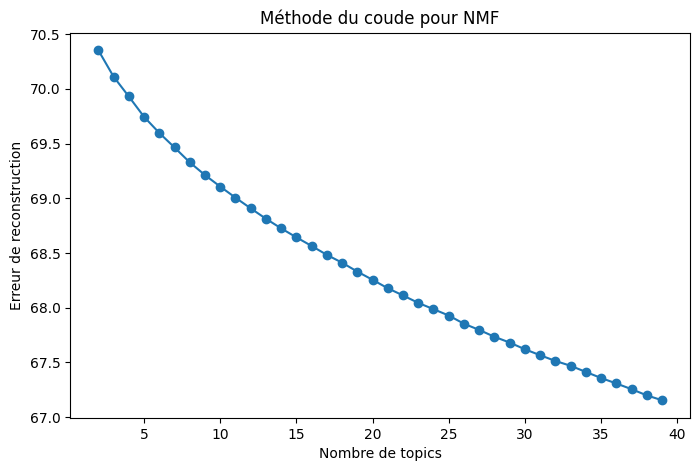

In [6]:
errors = []
k_values = range(2, 40)

for k in k_values:
    nmf = NMF(
        n_components=k,
        random_state=42,
        init="nndsvda",
        max_iter=2000
    )
    
    nmf.fit(X)
    errors.append(nmf.reconstruction_err_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, errors, marker="o")
plt.xlabel("Nombre de topics")
plt.ylabel("Erreur de reconstruction")
plt.title("Méthode du coude pour NMF")
plt.show()

- Apres avoir utilisé la méthode du coude nous ne trouvons **pas de coude clair**, ce qui rend difficile de choisir un K optimal pour la NMF. Il ne reste donc plus qu'à tester différents K et à observer les resultats obtenus pour choisir le K qui donne les topics les plus cohérents et les plus interprétables.

- Je vais tester les K suivants : **10, 15, 20, 30 et 35**.

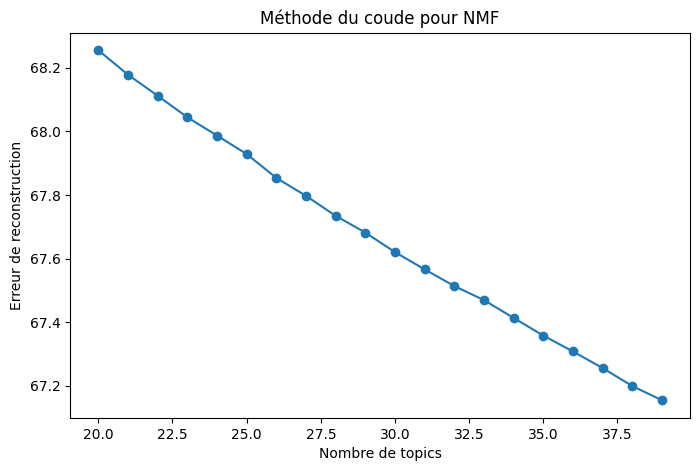

In [7]:
errors = []
k_values = range(20, 40)

for k in k_values:
    nmf = NMF(
        n_components=k,
        random_state=42,
        init="nndsvda",
        max_iter=2000
    )
    
    nmf.fit(X)
    errors.append(nmf.reconstruction_err_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, errors, marker="o")
plt.xlabel("Nombre de topics")
plt.ylabel("Erreur de reconstruction")
plt.title("Méthode du coude pour NMF")
plt.show()

# **Fonction pour afficher les topics et les mots les plus importants pour chaque topic**

In [8]:
def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")



feature_names = vectorizer.get_feature_names_out()

#for k in  [10, 15, 20, 30, 35 ]: # On teste différents nombres de topics (de 5 à 15) pour trouver le nombre optimal de topics pour notre analyse.
    
    #print(f"\n NMF avec {k} topics") 
nmf = NMF(n_components=29, 
          random_state=42,
          init="nndsvda",
          solver="cd",
          max_iter=1000,
          
            )
W = nmf.fit_transform(X)
H = nmf.components_
afficher_topics(nmf, feature_names)

print("Erreur :", nmf.reconstruction_err_)

Topic 1 : femme | mari | chose | bon | homme | cher | ménage | histoire | vrai | plaisir
Topic 2 : travail | peuple | vie | usine | bonheur | justice | ouvrier | œuvre | humanité | terre
Topic 3 : arbre | soleil | herbe | eau | ciel | jardin | ombre | terre | feuille | branche
Topic 4 : million | bourse | cours | action | universelle | banque | affaire | agent | hausse | titre
Topic 5 : abbé | prêtre | curé | église | jardin | trouche | soutane | sous | préfecture | évêque
Topic 6 : table | verre | vin | pain | café | eau | maman | assiette | bon | petit
Topic 7 : main | oeil | mort | bras | sang | tête | corps | face | voix | lèvre
Topic 8 : franc | argent | billet | somme | mois | sou | chiffre | pièce | fortune | poche
Topic 9 : monsieur | dame | porte | vou | bon | air | voix | tante | main | mot
Topic 10 : rue | maison | quartier | trottoir | boutique | boulevard | ville | place | voiture | chaussée
Topic 11 : train | gare | heure | machine | chef | voiture | voie | wagon | expres

In [9]:
noms_topics_nmf = {
    1: "Les relations conjugales et la vie domestique",
    2: "Le travail, le peuple et la justice sociale",
    3: "La nature et le paysage",
    4: "La bourse, la finance et les affaires",
    5: "Le clergé et la paroisse",
    6: "La table et les repas",
    7: "Le corps, la souffrance et la mort",
    8: "L’argent et la fortune",
    9: "Les conversations et les scènes domestiques",
    10: "Le quartier et la ville",
    11: "Le monde ferroviaire",
    12: "Le miracle, le pèlerinage et la religion",
    13: "Les liens familiaux, l’écriture et les proches",
    14: "Le pouvoir religieux",
    15: "L’école et l’instruction",
    16: "La famille, la terre et le monde paysan",
    17: "Le monde ouvrier et la mine",
    18: "La guerre, les soldats et l’armée",
    19: "Le désir, le mariage et les relations amoureuses",
    20: "Le magasin, la vente et les clientes",
    21: "Le monde médical et la santé",
    22: "Le monde artistique et la peinture",
    23: "La chambre, le lit et l’espace intime",
    24: "L’enfance, la maternité et la pauvreté",
    25: "Le commerce alimentaire et les halles",
    26: "Le salon, l’aristocratie et les scènes mondaines",
    27: "Le pouvoir politique et les affaires publiques",
    28: "L’amour, le bonheur et les sentiments",
    29: "L’insurrection et la révolution"
}

In [10]:
W_norm = W / W.sum(axis=1, keepdims=True)
# Normalisation de la matrice W pour que les contributions des topics soient comparables entre les segments de texte,
#en divisant chaque ligne de W par la somme de ses éléments. Cela permet d'obtenir des poids


df["topic_dominant"] = W_norm.argmax(axis=1) + 1
# On ajoute une colonne "topic_dominant" au DataFrame qui contient l'indice du topic dominant pour chaque segment de texte, 
# c'est-à-dire le topic avec la plus grande contribution dans la matrice W normalisée.

df["poids_topic"] = W_norm.max(axis=1)
# On ajoute une colonne "poids_topic" qui contient la valeur du poids du topic dominant pour chaque segment de texte,
# ce qui permet de mesurer à quel point le topic dominant est représentatif du segment de texte

# Attribution du nom du topic
df["nom_topic"] = df["topic_dominant"].map(noms_topics_nmf)

# Vérifications
print("Nombre de segments :", len(df))
print("Topics présents :", sorted(df["topic_dominant"].unique()))
print("Nombre de noms manquants :", df["nom_topic"].isna().sum())

Nombre de segments : 5327
Topics présents : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29)]
Nombre de noms manquants : 0


In [11]:
df # Affichage du DataFrame avec les nouvelles colonnes "topic_dominant" et "poids_topic".

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm,topic_dominant,poids_topic,nom_topic
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...,23,0.210721,"La chambre, le lit et l’espace intime"
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...,21,0.200500,Le monde médical et la santé
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...,21,0.177862,Le monde médical et la santé
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...,29,0.178062,L’insurrection et la révolution
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...,27,0.208460,Le pouvoir politique et les affaires publiques
...,...,...,...,...,...,...,...
5322,1894_1_Lourdes._clean.txt,193,"Le diable dans cette vie si pure, dans cette â...",diable vie pur âme péché coup souffrance pardo...,12,0.464836,"Le miracle, le pèlerinage et la religion"
5323,1894_1_Lourdes._clean.txt,194,Des milliers de pèlerins avaient beau se rendr...,millier pèlerin beau année peuple tentative ré...,12,0.347142,"Le miracle, le pèlerinage et la religion"
5324,1894_1_Lourdes._clean.txt,195,"Elle était sa maîtresse souveraine, elle le te...",maîtresse souverain milieu obscurité avortemen...,2,0.406650,"Le travail, le peuple et la justice sociale"
5325,1894_1_Lourdes._clean.txt,196,Et n’aurait-il pas fallu la venue d’un nouveau...,venue sauveur souffle prodigieux volée cloche ...,2,0.331730,"Le travail, le peuple et la justice sociale"


In [12]:
for topic in sorted(df["topic_dominant"].unique()):

    print(f"\n TOPIC {topic} ")
    subset = (
        df[df["topic_dominant"] == topic]
        .sort_values("poids_topic", ascending=False)
        .head(5)
    )
    for _, row in subset.iterrows():
        print(f"\nTitre : {row['nom_fichier']} | Poids : {row['poids_topic']:.4f}")
        print(row["phrases_paquet"])


 TOPIC 1 

Titre : 1880_9_Nana._clean.txt | Poids : 0.4935
mon cher, ils ne se sont jamais touchés, pas ça!... Elle était très portée là-dessus, tu comprends. Lui, godiche, n’a pas su... Si bien que, la croyant en bois, il est allé ailleurs avec des roulures qui l’ont régalé de toutes sortes d’horreurs, tandis qu’elle, de son côté, s’en payait d’aussi raides avec des garçons plus malins que son cornichon de mari... Et ça tourne toujours comme ça, faute de s’entendre. Je le sais bien, moi! Muffat, pâlissant, comprenant enfin les allusions, voulut la faire taire. Mais elle était lancée. Non, fiche-moi la paix!... Si vous n’étiez pas des mufes, vous seriez aussi gentils chez vos femmes que chez nous; et si vos femmes n’étaient pas des dindes, elles se donneraient pour vous garder la peine que nous prenons pour vous avoir... Tout ça, c’est des manières... Voilà, mon petit, mets ça dans ta poche. Ne parlez donc pas des honnêtes femmes, dit-il durement. Vous ne les connaissez pas. Du coup, 

In [13]:
df['nom_topic'].value_counts()

nom_topic
L’amour, le bonheur et les sentiments               335
La chambre, le lit et l’espace intime               327
Le pouvoir politique et les affaires publiques      266
Le salon, l’aristocratie et les scènes mondaines    266
Le travail, le peuple et la justice sociale         262
La nature et le paysage                             229
L’enfance, la maternité et la pauvreté              221
Le corps, la souffrance et la mort                  218
La table et les repas                               214
Le clergé et la paroisse                            210
Le quartier et la ville                             205
L’argent et la fortune                              187
Le monde ouvrier et la mine                         185
La famille, la terre et le monde paysan             180
Le miracle, le pèlerinage et la religion            177
Le désir, le mariage et les relations amoureuses    173
La guerre, les soldats et l’armée                   173
L’école et l’instruction              

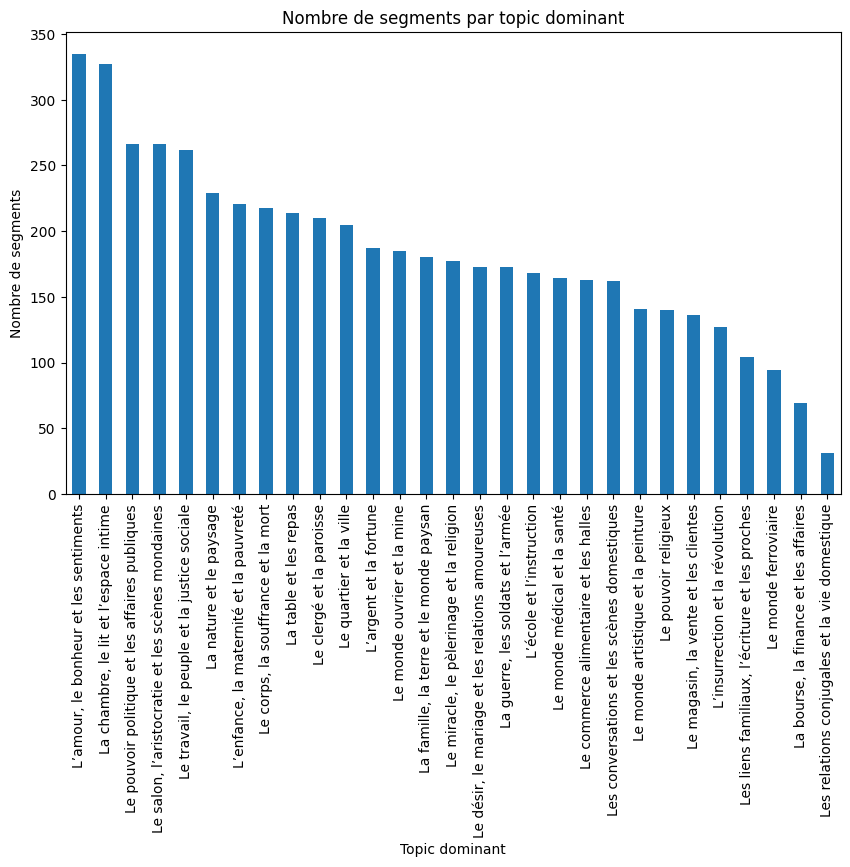

In [14]:
nb_segments = df["nom_topic"].value_counts()

plt.figure(figsize=(10, 6))
nb_segments.plot(kind="bar")

plt.title("Nombre de segments par topic dominant")
plt.xlabel("Topic dominant")
plt.ylabel("Nombre de segments")
plt.show()

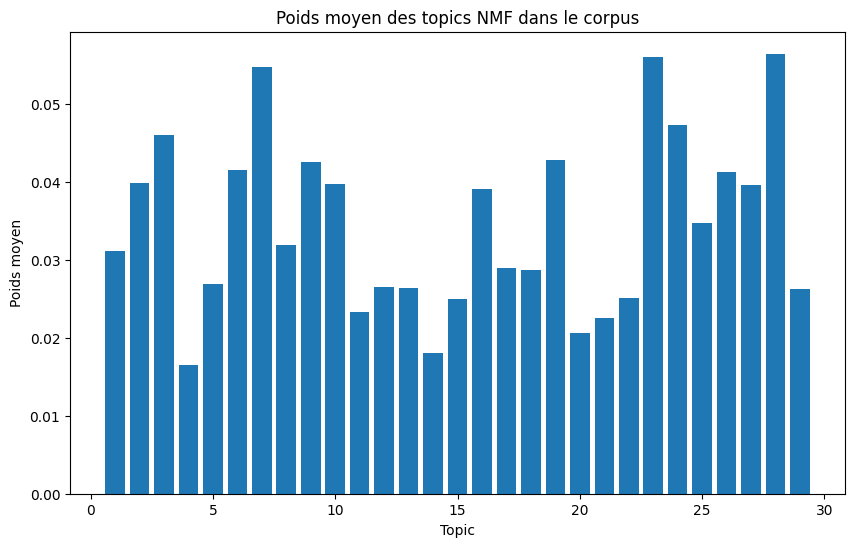

In [15]:
topic_weights = W_norm.mean(axis=0)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(topic_weights) + 1), topic_weights)

plt.title("Poids moyen des topics NMF dans le corpus")
plt.xlabel("Topic")
plt.ylabel("Poids moyen")
plt.show()

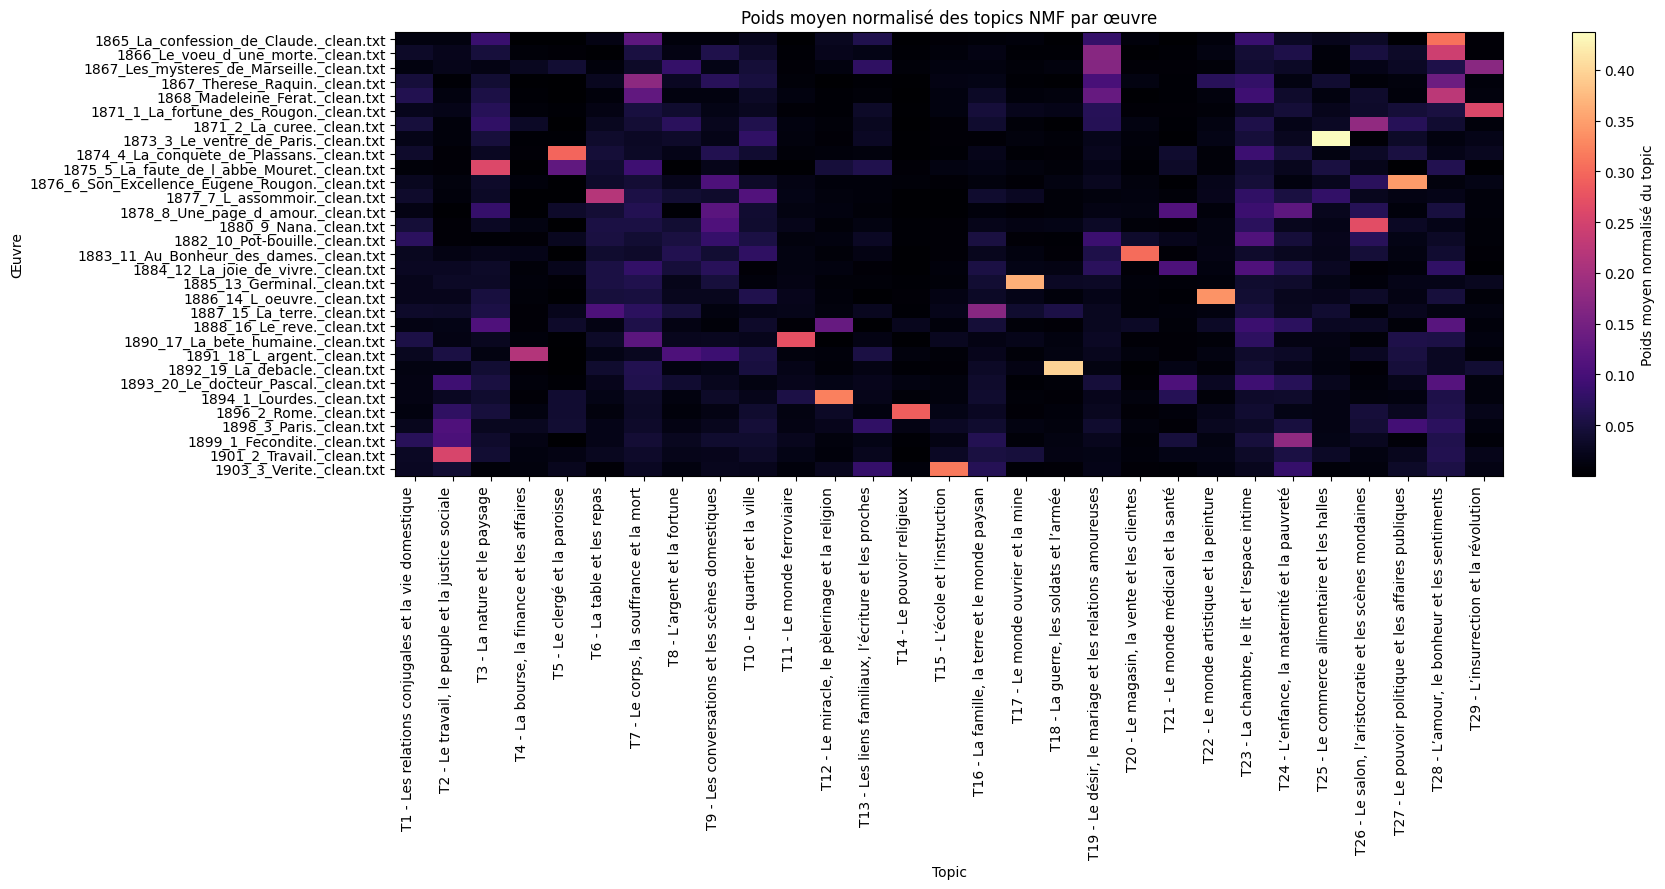

In [16]:
topic_labels = [
    f"T{i} - {noms_topics_nmf[i]}"
    for i in range(1, W.shape[1] + 1)
]

topics_df = pd.DataFrame(
    W_norm,
    columns=topic_labels
)

topics_df["nom_fichier"] = df["nom_fichier"].values

table_topics = topics_df.groupby("nom_fichier").mean()

plt.figure(figsize=(18, 9))
plt.imshow(table_topics, aspect="auto", cmap="magma")

plt.xticks(
    range(len(table_topics.columns)),
    table_topics.columns,
    rotation=90,
    ha="right"
)

plt.yticks(
    range(len(table_topics.index)),
    table_topics.index
)

plt.title("Poids moyen normalisé des topics NMF par œuvre")
plt.xlabel("Topic")
plt.ylabel("Œuvre")
plt.colorbar(label="Poids moyen normalisé du topic")
plt.tight_layout()
plt.show()

In [40]:
df["topic_label"] = df["topic_dominant"].map(

    lambda x: f"T{x} - {noms_topics_nmf[x]}"

)

ordre_topic_labels = [

    f"T{i} - {noms_topics_nmf[i]}"

    for i in range(1, 30)

]

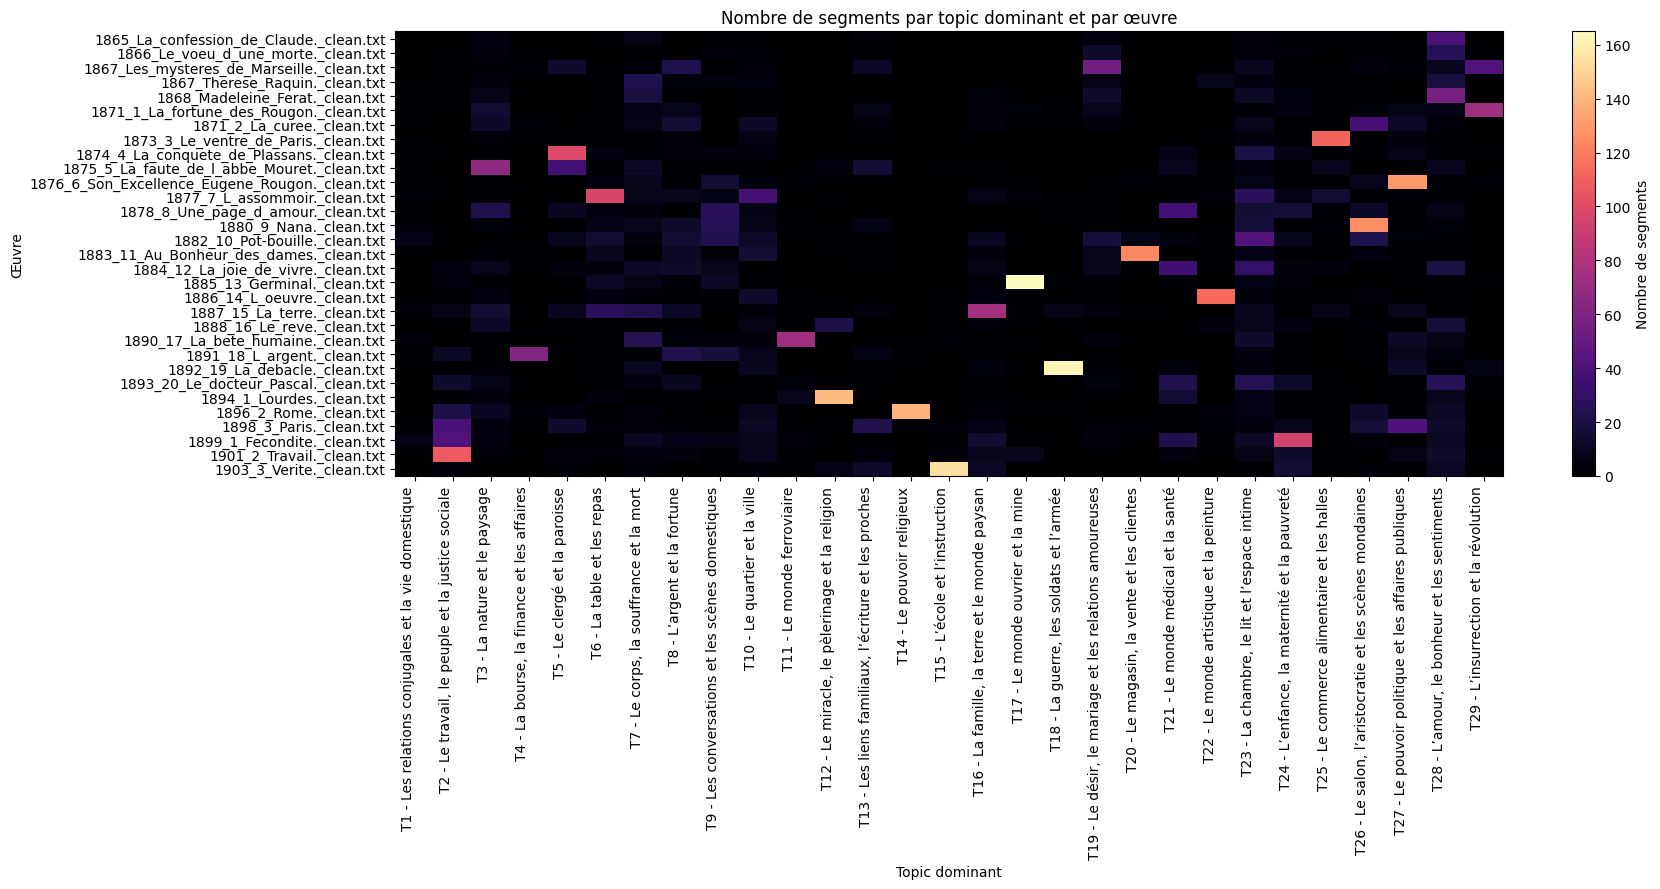

In [41]:
topic_counts = pd.crosstab(
    df["nom_fichier"],
    df["topic_label"]
)

topic_counts = topic_counts.reindex(
    columns=ordre_topic_labels,
    fill_value=0
)

plt.figure(figsize=(18, 9))
plt.imshow(topic_counts, aspect="auto", cmap="magma")

plt.xticks(
    range(len(topic_counts.columns)),
    topic_counts.columns,
    rotation=90,
    ha="right"
)

plt.yticks(
    range(len(topic_counts.index)),
    topic_counts.index
)

plt.title("Nombre de segments par topic dominant et par œuvre")
plt.xlabel("Topic dominant")
plt.ylabel("Œuvre")
plt.colorbar(label="Nombre de segments")
plt.tight_layout()
plt.show()

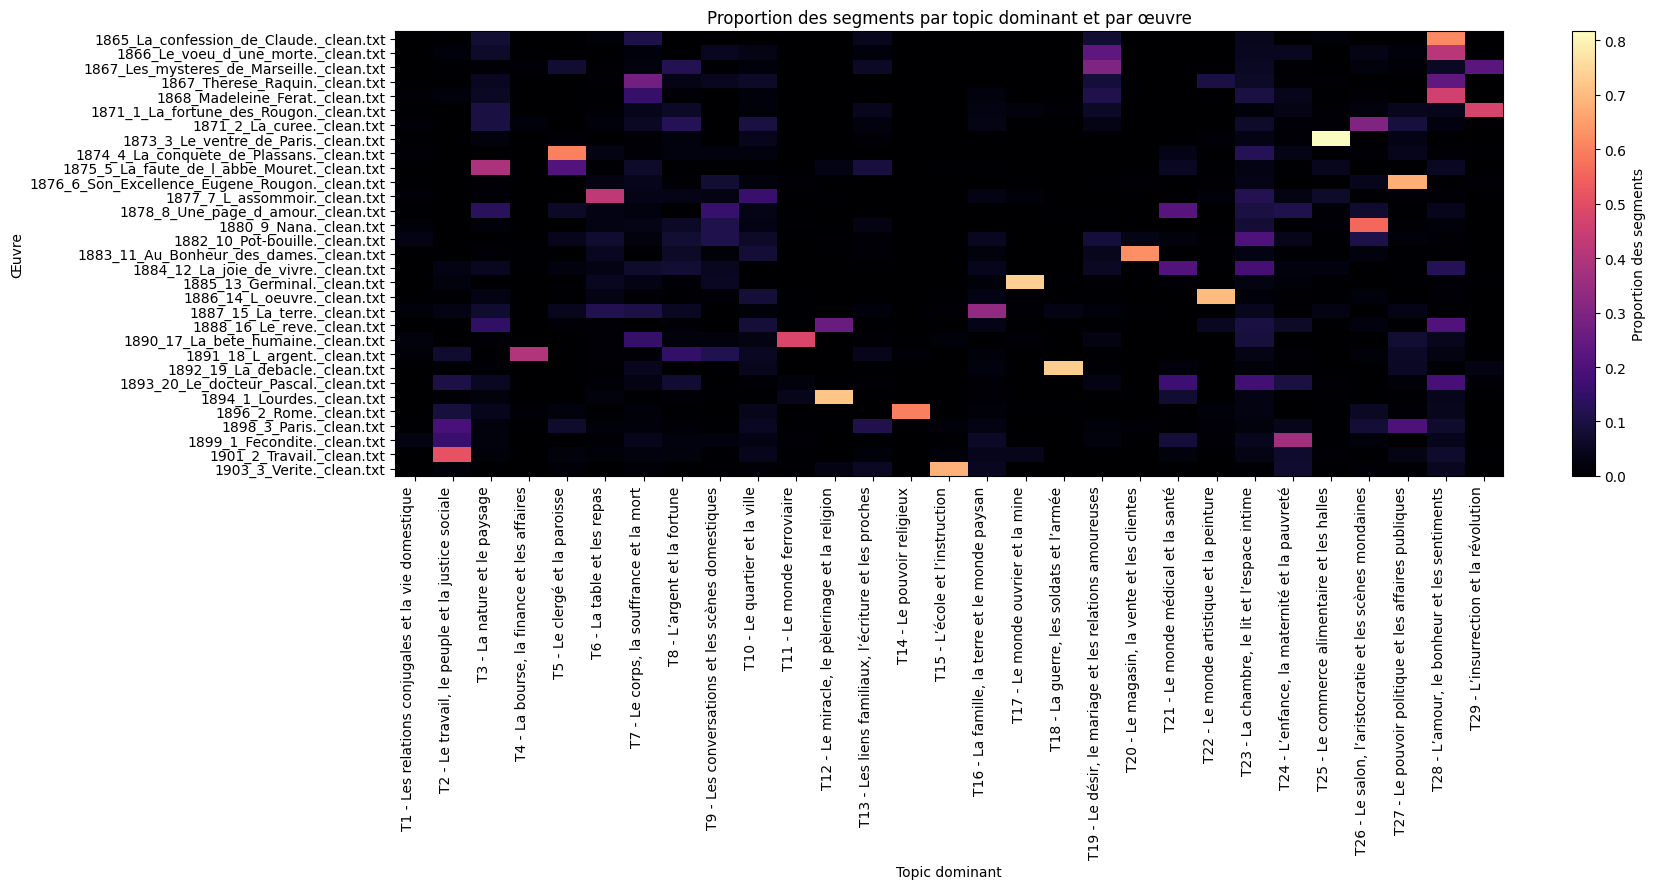

In [42]:
topic_props = topic_counts.div(topic_counts.sum(axis=1), axis=0)

plt.figure(figsize=(18, 9))
plt.imshow(topic_props, aspect="auto", cmap="magma")

plt.xticks(
    range(len(topic_props.columns)),
    topic_props.columns,
    rotation=90,
    ha="right"
)

plt.yticks(
    range(len(topic_props.index)),
    topic_props.index
)

plt.title("Proportion des segments par topic dominant et par œuvre")
plt.xlabel("Topic dominant")
plt.ylabel("Œuvre")
plt.colorbar(label="Proportion des segments")
plt.tight_layout()
plt.show()